# Automated Project Similarity Detection Using NLP Techniques

## load the dataset

In [118]:
import pandas as pd

df = pd.read_csv("project similarity dataset.csv")
df.head()


,TITLE OF THE PROJECT,DOMAIN USED IN THE PROJECT,ALGORITHMS USED IN THE PROJECT,DATASET USED(Name & Link)
0,SKIN CANCER DETECTION USING CNN,DEEP LEARNING,CNN,NaN
1,Hands-free home: Voice Activated fan and light...,IOT,Arduino Uno,NaN
2,IoT Based Hand Gestures Control Light System,IoT,"Used python libraries such as open cv, mediapi...",Didn't used any dataset
3,IoT Based Underground Cable Fault Detector,IoT,"Sensor reading, Fault Detection and Location, ...",NaN
4,Solar Adaptive Lightning System,IoT,Rule Based Control Algorithm,Not Used


In [119]:
print(df.columns)


Index(['TITLE OF THE PROJECT', 'DOMAIN USED IN THE PROJECT',
       'ALGORITHMS USED IN THE PROJECT', 'DATASET USED(Name & Link)'],
      dtype='object')


In [120]:
df = df.fillna("")


In [121]:
print("Total projects:", len(df))
df[["TITLE OF THE PROJECT", "ALGORITHMS USED IN THE PROJECT", "DOMAIN USED IN THE PROJECT"]].head()


Total projects: 65


,TITLE OF THE PROJECT,ALGORITHMS USED IN THE PROJECT,DOMAIN USED IN THE PROJECT
0,SKIN CANCER DETECTION USING CNN,CNN,DEEP LEARNING
1,Hands-free home: Voice Activated fan and light...,Arduino Uno,IOT
2,IoT Based Hand Gestures Control Light System,"Used python libraries such as open cv, mediapi...",IoT
3,IoT Based Underground Cable Fault Detector,"Sensor reading, Fault Detection and Location, ...",IoT
4,Solar Adaptive Lightning System,Rule Based Control Algorithm,IoT


## Text Cleaning & Preprocessing

In [122]:
##import re
##import nltk
##from nltk.corpus import stopwords


##nltk.download('stopwords')
##stop_words = set(stopwords.words('english'))

In [123]:
import re

def clean_text(text):
    text = str(text).lower()                 # lowercase
    text = re.sub(r'[^a-z0-9 ]', ' ', text)  # remove symbols
    text = re.sub(r'\s+', ' ', text)         # remove extra spaces
    return text.strip()


In [124]:
df["clean_title"] = df["TITLE OF THE PROJECT"].apply(clean_text)
df["clean_algorithms"] = df["ALGORITHMS USED IN THE PROJECT"].apply(clean_text)
df["clean_technique"] = df["DOMAIN USED IN THE PROJECT"].apply(clean_text)


In [125]:
df[["clean_title", "clean_algorithms", "clean_technique"]].head(5)


,clean_title,clean_algorithms,clean_technique
0,skin cancer detection using cnn,cnn,deep learning
1,hands free home voice activated fan and light ...,arduino uno,iot
2,iot based hand gestures control light system,used python libraries such as open cv mediapip...,iot
3,iot based underground cable fault detector,sensor reading fault detection and location sm...,iot
4,solar adaptive lightning system,rule based control algorithm,iot


## User Input Module (Core System Entry Point)

In [126]:
user_title = input("Enter Project Title: ")
user_algorithms = input("Enter Algorithms Used: ")
user_domain = input("Enter Domain / Techniques: ")


Enter Project Title:  COMPUTER AIDED BREAST CANCER DETECTION
Enter Algorithms Used:  cnn,transfer learning
Enter Domain / Techniques:  deep learning


## Title Similarity (TF-IDF + Cosine Similarity)

In [127]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [128]:
# Combine dataset titles with user title
all_titles = df["clean_title"].tolist() + [user_title]

vectorizer = TfidfVectorizer()
title_vectors = vectorizer.fit_transform(all_titles)


In [129]:
user_title_vec = title_vectors[-1]      # last row = user input
dataset_title_vecs = title_vectors[:-1]

df["title_similarity"] = cosine_similarity(user_title_vec, dataset_title_vecs)[0]


In [130]:
df[["TITLE OF THE PROJECT", "title_similarity"]].sort_values("title_similarity", ascending=False).head(10)


,TITLE OF THE PROJECT,title_similarity
45,COMPUTER AIDED BREAST CANCER DETECTION,1.000000
22,Computer Aided Breast Cancer Detection using C...,0.741934
0,SKIN CANCER DETECTION USING CNN,0.307857
35,Lung Disease And Cancer Prediction Using SVM A...,0.128186
16,Smoke detection,0.125125
58,DETECTION OF PNUEMONIA USING DEEP LEARNING,0.082735
8,Automated crop disease detection using CNN,0.082218
24,Underground cable fault detection system,0.080763
37,Crop Disease Detection Using Quantum and Deep ...,0.077637
19,Blob detection based system for medical analysis,0.070361


## Algorithm Similarity

In [131]:
# Dictionary of algorithm keywords to standard names
algo_map = {
    # ML / AI models
    "cnn": "cnn",
    "convolutional neural network": "cnn",
    "random forest": "random_forest",
    "decision tree": "decision_tree",
    "logistic regression": "logistic_regression",
    "svm": "svm",
    "support vector machine": "svm",
    "knn": "knn",
    "yolo": "yolo",
    "arima": "arima",
    "gan": "gan",
    "auto encoder": "autoencoder",
    "autoencoder": "autoencoder",
    "mobilenet": "mobilenet",
    "resnet": "resnet",
    "vgg": "vgg",
    "inception": "inception",
    "efficientnet": "efficientnet",
    "qsvm": "qsvm",
    "llm": "llm",
    "llama": "llm",
    "transformer": "transformer",

    # Rule-based / control
    "rule-based": "rule_based",
    "threshold-based": "threshold_based",
    "event-driven": "event_driven",
    "time-based": "time_based",

    # Text similarity algorithms (YOU chose to keep)
    "tf-idf": "tfidf",
    "tf idf": "tfidf",
    "cosine": "cosine_similarity",
    "cosine similarity": "cosine_similarity" ,
    "jaccard similarity": "jaccard_similarity" ,
}


In [132]:
def extract_algorithms_strict(text):
    text = str(text).lower()
    found_algos = set()
    
    for key, standard_name in algo_map.items():
        if key in text:
            found_algos.add(standard_name)
    
    if len(found_algos) == 0:
        return "none"   # <-- IMPORTANT
    
    return " ".join(sorted(found_algos))


In [133]:
df["clean_algorithms_final"] = df["ALGORITHMS USED IN THE PROJECT"].apply(extract_algorithms_strict)


In [134]:
df[["ALGORITHMS USED IN THE PROJECT", "clean_algorithms_final"]].head(20)


,ALGORITHMS USED IN THE PROJECT,clean_algorithms_final
0,CNN,cnn
1,Arduino Uno,none
2,"Used python libraries such as open cv, mediapi...",none
3,"Sensor reading, Fault Detection and Location, ...",none
4,Rule Based Control Algorithm,none
5,Decision Tree and Random Forest,decision_tree random_forest
6,Logistic regression and decision trees,decision_tree logistic_regression
7,Face Detection Algorithm\nEye Aspect Ratio (EA...,none
8,"CNN, computer vision",cnn
9,Arima,arima


In [135]:
df["clean_algorithms_final"].value_counts()


clean_algorithms_final
none                                  28
cnn                                   11
rule_based                             4
threshold_based                        3
svm                                    2
decision_tree random_forest            2
qsvm svm                               1
efficientnet                           1
autoencoder gan                        1
logistic_regression                    1
llm                                    1
rule_based yolo                        1
inception resnet vgg                   1
event_driven rule_based time_based     1
cnn yolo                               1
cnn mobilenet                          1
cosine_similarity knn tfidf            1
cnn logistic_regression mobilenet      1
arima                                  1
decision_tree logistic_regression      1
random_forest                          1
Name: count, dtype: int64

In [136]:
user_algorithms_clean = extract_algorithms_strict(user_algorithms)
print("User Clean Algorithms:", user_algorithms_clean)


User Clean Algorithms: cnn


In [137]:
def jaccard_similarity(a, b):
    set_a = set(a.split())
    set_b = set(b.split())
    
    if "none" in set_a and "none" in set_b:
        return 1.0
    if len(set_a.union(set_b)) == 0:
        return 0
    
    return len(set_a & set_b) / len(set_a | set_b)


In [138]:
df["algo_similarity"] = df["clean_algorithms_final"].apply(lambda x: jaccard_similarity(user_algorithms_clean, x))


In [139]:
df[["TITLE OF THE PROJECT", "clean_algorithms_final", "algo_similarity"]].sort_values("algo_similarity", ascending=False).head(10)


,TITLE OF THE PROJECT,clean_algorithms_final,algo_similarity
0,SKIN CANCER DETECTION USING CNN,cnn,1.0
14,Enhancing Tuberculosis Detection through Deep ...,cnn,1.0
28,Image Debluring using neural networks,cnn,1.0
45,COMPUTER AIDED BREAST CANCER DETECTION,cnn,1.0
47,Urban Change Detection Using Deep Multi-Scale ...,cnn,1.0
23,TOURISM PLANNING ASSISTANT USING CNN,cnn,1.0
48,Plant Disease Prediction: A Comparison of Deep...,cnn,1.0
53,ENHANCED TUBERCULOSIS DETECTION USING DEEP LEA...,cnn,1.0
15,AI-Powered Skin Product Recommendation using ...,cnn,1.0
38,Deep Learning–Based Plant Disease Detection wi...,cnn,1.0


## Domain / Technique Cleaning

In [140]:
domain_map = {
    # AI / ML domains
    "machine learning": "ml",
    "ml": "ml",
    "deep learning": "dl",
    "dl": "dl",
    "artificial intelligence": "ai",
    "ai": "ai",
    "computer vision": "computer_vision",
    "image processing": "computer_vision",
    "nlp": "nlp",
    "natural language": "nlp",
    "llm": "nlp",
    "generative ai": "ai",

    # IoT / Embedded
    "iot": "iot",
    "internet of things": "iot",
    "embedded": "embedded_systems",

    # Other domains
    "data science": "data_science",
    "blockchain": "blockchain",
    "cyber": "cyber_security",
    "web": "web",
    "agriculture": "agriculture",
    "healthcare": "healthcare",
    "quantum": "quantum_computing"
}

In [141]:
def extract_domain_strict(text):
    text = str(text).lower()
    found = set()
    
    for key, value in domain_map.items():
        if key in text:
            found.add(value)
    
    if len(found) == 0:
        return "none"
    
    return " ".join(sorted(found))


In [142]:
df["clean_domain_final"] = df["DOMAIN USED IN THE PROJECT"].apply(extract_domain_strict)


In [143]:
user_domain_clean = extract_domain_strict(user_domain)
print("User Technique Clean:", user_domain_clean)


User Technique Clean: dl


In [144]:
df[["DOMAIN USED IN THE PROJECT", "clean_domain_final"]].head(20)


,DOMAIN USED IN THE PROJECT,clean_domain_final
0,DEEP LEARNING,dl
1,IOT,iot
2,IoT,iot
3,IoT,iot
4,IoT,iot
5,Machine Learning,ml
6,Machine learning,ml
7,Artificial Intelligence (AI) and Machine Learn...,ai computer_vision ml
8,Agriculture,agriculture
9,Healthcare,healthcare


In [145]:
df["clean_domain_final"].value_counts().head(20)


clean_domain_final
iot                        24
dl                         12
ml                          6
dl ml                       4
ai dl                       3
ai computer_vision ml       2
dl ml quantum_computing     1
none                        1
ml quantum_computing        1
ai ml nlp                   1
web                         1
dl nlp                      1
ai blockchain web           1
embedded_systems iot        1
dl healthcare               1
nlp quantum_computing       1
data_science                1
healthcare                  1
agriculture                 1
ai                          1
Name: count, dtype: int64

## Domain / Technique Similarity Computation

In [146]:
def jaccard_similarity(a, b):
    set_a = set(a.split())
    set_b = set(b.split())
    
    if "none" in set_a and "none" in set_b:
        return 1.0
    if len(set_a.union(set_b)) == 0:
        return 0
    
    return len(set_a & set_b) / len(set_a | set_b)


In [147]:
df["domain_similarity"] = df["clean_domain_final"].apply(lambda x: jaccard_similarity(user_domain_clean, x))


In [148]:
df[["TITLE OF THE PROJECT", "clean_domain_final", "domain_similarity"]].sort_values("domain_similarity", ascending=False).head(10)


,TITLE OF THE PROJECT,clean_domain_final,domain_similarity
0,SKIN CANCER DETECTION USING CNN,dl,1.0
10,Deep Learning Framework for Osteoporosis Detec...,dl,1.0
40,A Multimodal Approach to Adaptive \nCrop Advisory,dl,1.0
31,A Multimodal Approach to Adaptive \nCrop Advisory,dl,1.0
30,Automatic Garbage Littering Violation Enforcem...,dl,1.0
28,Image Debluring using neural networks,dl,1.0
47,Urban Change Detection Using Deep Multi-Scale ...,dl,1.0
23,TOURISM PLANNING ASSISTANT USING CNN,dl,1.0
51,A comprehensive evaluation of image processing...,dl,1.0
53,ENHANCED TUBERCULOSIS DETECTION USING DEEP LEA...,dl,1.0


In [149]:
df[["TITLE OF THE PROJECT","clean_domain_final","domain_similarity"]].head(10)


,TITLE OF THE PROJECT,clean_domain_final,domain_similarity
0,SKIN CANCER DETECTION USING CNN,dl,1.0
1,Hands-free home: Voice Activated fan and light...,iot,0.0
2,IoT Based Hand Gestures Control Light System,iot,0.0
3,IoT Based Underground Cable Fault Detector,iot,0.0
4,Solar Adaptive Lightning System,iot,0.0
5,Digital Addiction & Parental Control System us...,ml,0.0
6,App drop-off prediction using machine learning,ml,0.0
7,NEURODRIVE: ML-Powered Driver Monitoring System,ai computer_vision ml,0.0
8,Automated crop disease detection using CNN,agriculture,0.0
9,Heart rate analysis using arima,healthcare,0.0


## Retrieve Top 5 Similar Projects (Title + Algo + Domain Combined Ranking)

In [150]:
df["rank_score"] = (
    0.6 * df["title_similarity"] +
    0.2 * df["algo_similarity"] +
    0.2 * df["domain_similarity"]
)


In [151]:
top10 = df.sort_values("rank_score", ascending=False).head(5)


top5[["TITLE OF THE PROJECT", "title_similarity", "algo_similarity", "domain_similarity", "rank_score"]]


,TITLE OF THE PROJECT,title_similarity,algo_similarity,domain_similarity,rank_score
45,COMPUTER AIDED BREAST CANCER DETECTION,1.000000,1.0,0.5,0.900000
0,SKIN CANCER DETECTION USING CNN,0.307857,1.0,1.0,0.584714
22,Computer Aided Breast Cancer Detection using C...,0.741934,0.0,0.5,0.545160
53,ENHANCED TUBERCULOSIS DETECTION USING DEEP LEA...,0.056985,1.0,1.0,0.434191
47,Urban Change Detection Using Deep Multi-Scale ...,0.054061,1.0,1.0,0.432436


## Your Recommendation Logic

In [152]:
TITLE_TH = 0.5
ALGO_TH = 0.4
DOMAIN_TH = 0.4


In [153]:
def recommendation_logic(title_sim, algo_sim, domain_sim):
    
    # Case 1: Title high & domain high
    if title_sim >= TITLE_TH and domain_sim >= DOMAIN_TH:
        if algo_sim >= ALGO_TH:
            return "CHANGE PROJECT IDEA (Duplicate Project)"
        else:
            return "MODIFY APPROACH / METHODOLOGY"
    
    # Case 2: Title high but domain low
    elif title_sim >= TITLE_TH and domain_sim < DOMAIN_TH:
        return "CHANGE TITLE"
    
    # Case 3: Title low
    else:
        return "GOOD TO GO (Unique Project)"


In [154]:
top5["recommendation"] = top5.apply(lambda row: recommendation_logic(
    row["title_similarity"],
    row["algo_similarity"],
    row["domain_similarity"]
), axis=1)

top5[["TITLE OF THE PROJECT", "title_similarity", "algo_similarity", "domain_similarity", "recommendation"]]


,TITLE OF THE PROJECT,title_similarity,algo_similarity,domain_similarity,recommendation
45,COMPUTER AIDED BREAST CANCER DETECTION,1.000000,1.0,0.5,CHANGE PROJECT IDEA (Duplicate Project)
0,SKIN CANCER DETECTION USING CNN,0.307857,1.0,1.0,GOOD TO GO (Unique Project)
22,Computer Aided Breast Cancer Detection using C...,0.741934,0.0,0.5,MODIFY APPROACH / METHODOLOGY
53,ENHANCED TUBERCULOSIS DETECTION USING DEEP LEA...,0.056985,1.0,1.0,GOOD TO GO (Unique Project)
47,Urban Change Detection Using Deep Multi-Scale ...,0.054061,1.0,1.0,GOOD TO GO (Unique Project)


In [155]:
top5[["TITLE OF THE PROJECT","recommendation"]]


,TITLE OF THE PROJECT,recommendation
45,COMPUTER AIDED BREAST CANCER DETECTION,CHANGE PROJECT IDEA (Duplicate Project)
0,SKIN CANCER DETECTION USING CNN,GOOD TO GO (Unique Project)
22,Computer Aided Breast Cancer Detection using C...,MODIFY APPROACH / METHODOLOGY
53,ENHANCED TUBERCULOSIS DETECTION USING DEEP LEA...,GOOD TO GO (Unique Project)
47,Urban Change Detection Using Deep Multi-Scale ...,GOOD TO GO (Unique Project)


## Click a Top-5 Project → Show Full Details

In [156]:
def get_project_details(project_title):
    row = df[df["TITLE OF THE PROJECT"] == project_title]
    return row


In [157]:
selected_project = top5.iloc[0]["TITLE OF THE PROJECT"]
details = get_project_details(selected_project)
details


,TITLE OF THE PROJECT,DOMAIN USED IN THE PROJECT,ALGORITHMS USED IN THE PROJECT,DATASET USED(Name & Link),clean_title,clean_algorithms,clean_technique,title_similarity,clean_algorithms_final,algo_similarity,clean_domain_final,domain_similarity,rank_score
45,COMPUTER AIDED BREAST CANCER DETECTION,"Artificial Intelligence, Deep Learning","CNN, Transfer Learning.",,computer aided breast cancer detection,cnn transfer learning,artificial intelligence deep learning,1.0,cnn,1.0,ai dl,0.5,0.9


In [158]:
def display_project_result(title):
    row = df[df["TITLE OF THE PROJECT"] == title].iloc[0]
    
    rec = recommendation_logic(row["title_similarity"], row["algo_similarity"], row["domain_similarity"])
    
    print("PROJECT:", row["TITLE OF THE PROJECT"])
    print("DOMAIN:", row["DOMAIN USED IN THE PROJECT"])
    print("ALGORITHMS:", row["ALGORITHMS USED IN THE PROJECT"])
    print("DATASET:", row["DATASET USED(Name & Link)"])
    
    print("\nSimilarity Scores:")
    print("Title:", row["title_similarity"])
    print("Algorithm:", row["algo_similarity"])
    print("Domain:", row["domain_similarity"])
    
    print("\nRecommendation:", rec)


In [159]:
display_project_result(selected_project)


PROJECT: COMPUTER AIDED BREAST CANCER DETECTION
DOMAIN: Artificial Intelligence, Deep Learning 
ALGORITHMS: CNN, Transfer Learning. 
DATASET: 

Similarity Scores:
Title: 1.0
Algorithm: 1.0
Domain: 0.5

Recommendation: CHANGE PROJECT IDEA (Duplicate Project)


In [160]:
selected_project = top5.iloc[0]["TITLE OF THE PROJECT"]
display_project_result(selected_project)


PROJECT: COMPUTER AIDED BREAST CANCER DETECTION
DOMAIN: Artificial Intelligence, Deep Learning 
ALGORITHMS: CNN, Transfer Learning. 
DATASET: 

Similarity Scores:
Title: 1.0
Algorithm: 1.0
Domain: 0.5

Recommendation: CHANGE PROJECT IDEA (Duplicate Project)


## Evaluation Metrics

In [161]:
import pandas as pd

df = pd.read_csv("merged_project_dataset.csv")
print(df.shape)
df.head()


(1065, 5)


,TITLE OF THE PROJECT,DOMAIN USED IN THE PROJECT,ALGORITHMS USED IN THE PROJECT,DATASET USED(Name & Link),data_source
0,SKIN CANCER DETECTION USING CNN,DEEP LEARNING,CNN,NaN,real
1,Hands-free home: Voice Activated fan and light...,IOT,Arduino Uno,NaN,real
2,IoT Based Hand Gestures Control Light System,IoT,"Used python libraries such as open cv, mediapi...",Didn't used any dataset,real
3,IoT Based Underground Cable Fault Detector,IoT,"Sensor reading, Fault Detection and Location, ...",NaN,real
4,Solar Adaptive Lightning System,IoT,Rule Based Control Algorithm,Not Used,real


In [162]:
def assign_topic(title):
    title = str(title).lower()
    
    if "plant" in title or "crop" in title:
        return "plant_disease"
    elif "cancer" in title or "tumor" in title or "pneumonia" in title or "disease" in title:
        return "medical"
    elif "iot" in title or "smart" in title or "sensor" in title or "automation" in title:
        return "iot"
    elif "chatbot" in title or "nlp" in title or "sentiment" in title or "text" in title:
        return "nlp"
    else:
        return "other"


In [163]:
df["topic_label"] = df["TITLE OF THE PROJECT"].apply(assign_topic)
df["topic_label"].value_counts()


topic_label
other            440
iot              163
plant_disease    157
medical          155
nlp              150
Name: count, dtype: int64

In [164]:
df["true_label"] = df["topic_label"].apply(lambda x: 1 if x!="other" else 0)


In [165]:
df["topic_label"] = df["TITLE OF THE PROJECT"].apply(assign_topic)
df["topic_label"].value_counts()


topic_label
other            440
iot              163
plant_disease    157
medical          155
nlp              150
Name: count, dtype: int64

In [166]:
df["true_label"] = df["topic_label"].apply(lambda x: 1 if x!="other" else 0)


In [167]:
query_index = 0   # change this number to test other projects
query_title = df.loc[query_index, "TITLE OF THE PROJECT"]
query_topic = df.loc[query_index, "topic_label"]

print("Query Project:", query_title)
print("Query Topic:", query_topic)


Query Project: SKIN CANCER DETECTION USING CNN 
Query Topic: medical


In [168]:
df["true_label"] = (df["topic_label"] == query_topic).astype(int)
df["true_label"].value_counts()


true_label
0    910
1    155
Name: count, dtype: int64

In [169]:
top5_titles = top5["TITLE OF THE PROJECT"].tolist()
print(top5_titles)


['COMPUTER AIDED BREAST CANCER DETECTION', 'SKIN CANCER DETECTION USING CNN ', 'Computer Aided Breast Cancer Detection using CNN and Transfer Learning', 'ENHANCED TUBERCULOSIS DETECTION USING DEEP LEARNING THROUGH CHEST X-RAY SCANS', 'Urban Change Detection Using Deep Multi-Scale Vision Networks']


In [170]:
df["predicted_similar"] = df["TITLE OF THE PROJECT"].isin(top5_titles).astype(int)
df["predicted_similar"].value_counts()


predicted_similar
0    1060
1       5
Name: count, dtype: int64

In [171]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Example predicted (your model output)
# Mark top 5 similar as 1
top5_titles = top5["TITLE OF THE PROJECT"].tolist()
df["predicted_similar"] = df["TITLE OF THE PROJECT"].apply(lambda x: 1 if x in top5_titles else 0)

precision = precision_score(df["true_label"], df["predicted_similar"])
recall = recall_score(df["true_label"], df["predicted_similar"])
f1 = f1_score(df["true_label"], df["predicted_similar"])

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.6
Recall: 0.01935483870967742
F1 Score: 0.0375


In [172]:
y_true = df["true_label"]
y_pred = df["predicted_similar"]

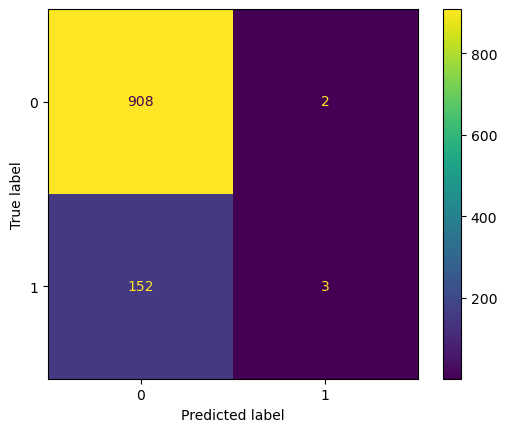

In [173]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.86      1.00      0.92       910
           1       0.60      0.02      0.04       155

    accuracy                           0.86      1065
   macro avg       0.73      0.51      0.48      1065
weighted avg       0.82      0.86      0.79      1065



In [60]:
true_similar_titles = df[df["true_label"] == 1]["TITLE OF THE PROJECT"].tolist()
precision_at_5 = len(set(top5_titles) & set(true_similar_titles)) / 5
print("Precision@5:", precision_at_5)


Precision@5: 0.6


In [61]:
recall_at_5 = len(set(top5_titles) & set(true_similar_titles)) / len(true_similar_titles)
print("Recall@5:", recall_at_5)


Recall@5: 0.01935483870967742
